In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

In [25]:
n = 10
I = np.identity(2*n)
L = 1 / (n ** 2) * np.block([
    [np.zeros((n,n)), np.zeros((n,n))],
    [np.ones((n,n)), np.zeros((n,n))]])
A = I - L - L.T
C = np.linalg.inv(I-L) @ L.T
S = np.diag([1/(2*n) for i in range(2*n)])
R = I - S @ np.linalg.inv(I) @ A

4.605170185988091 4.60517018598809


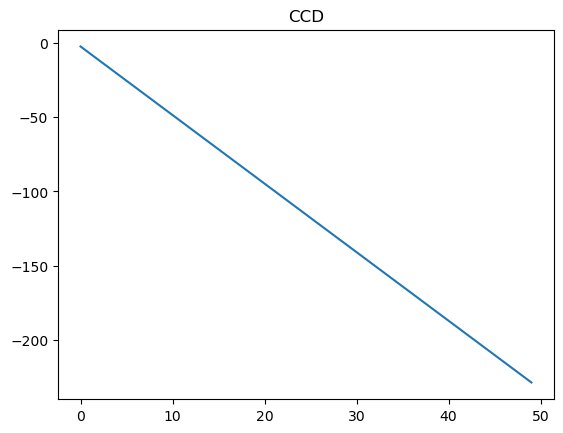

In [26]:
epochs = 50
x0 = np.ones((2 * n,1))
x = x0.copy()
x_star = np.zeros((2 * n,1))
ccd_errors = []
for l in range(epochs):
    x = C @ x
    ratio = np.linalg.norm(x - x_star) / np.linalg.norm(x0 - x_star)
    ccd_errors.append(np.log(ratio))

rho_C = np.max(np.abs(np.linalg.eigvals(C)))
ccd_rate = -np.log(rho_C)
slope, intercept = np.polyfit(range(epochs), ccd_errors, 1)
plt.plot(ccd_errors)
plt.title("CCD")
print(ccd_rate, -slope)

0.04604393850140708 0.046043938501406874


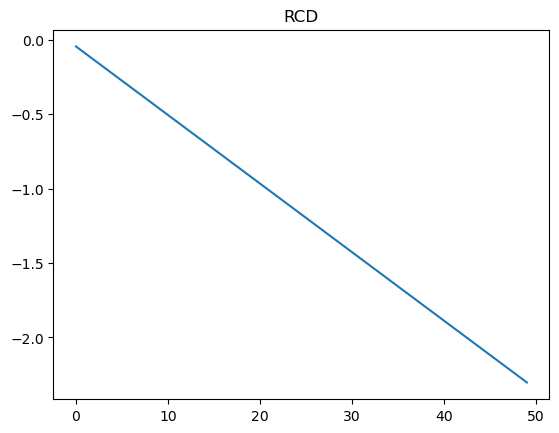

In [28]:
x0 = np.ones((2 * n,1))
x = x0.copy()
x_star = np.zeros((2 * n,1))
rcd_errors = []

for l in range(epochs):
    x = R @ x
    ratio = np.linalg.norm(x - x_star) / np.linalg.norm(x0 - x_star)
    rcd_errors.append(np.log(ratio))

rho_R = np.max(np.abs(np.linalg.eigvals(R)))
rcd_rate = -np.log(rho_R)
slope, intercept = np.polyfit(range(epochs), rcd_errors, 1)
plt.plot(rcd_errors)
plt.title("RCD")
print(rcd_rate, -slope)

In [30]:
float(ccd_rate / rcd_rate)

100.01686076110451

### Simple Case with $A_c$

In [27]:
n = 2
c = 0.1
matrix = c * np.ones((n, n))
path = None
L = np.tril(matrix, k=-1) # moves boundary one step below the diagonal
A_c = np.identity(2) + L + L.T
A_1 = np.array([[0, -c],
                 [0, 1]])
A_2 = np.array([[1, 0],
                 [-c, 0]])

Text(0.5, 1.0, 'PRCD')

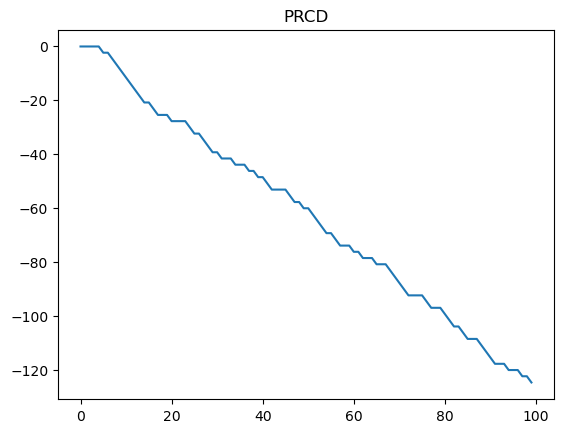

In [28]:
epochs = 100
x0 = np.ones((n,1))
x = x0.copy()
x_star = np.zeros((n,1))
prcd_errors = []

for l in range(epochs):
    if random.random() < 0.5:
        path = 1 # A1
    else:
        path = 0 # A2

    if path == 1:
        x = A_1 @ x
    else:
        x = A_2 @ x

    ratio = np.linalg.norm(x - x_star) / np.linalg.norm(x0 - x_star)
    prcd_errors.append(np.log(ratio))

plt.plot(prcd_errors)
plt.title("PRCD")

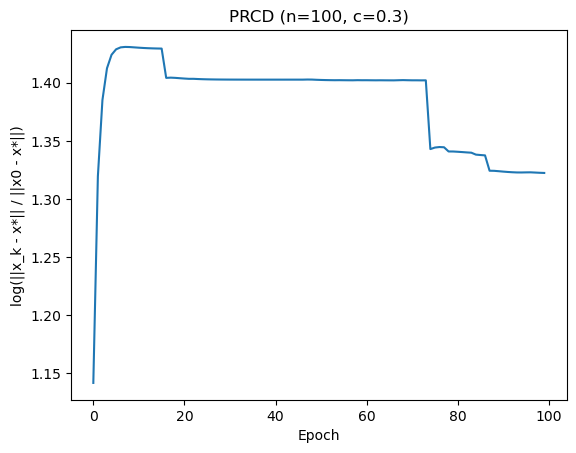

In [31]:
import numpy as np
import random
import matplotlib.pyplot as plt

n = 100 # change to any n
c = 0.3  # keep c < 1/(n-1) for positive definiteness

# Build A_c
A_c = c * np.ones((n, n))
np.fill_diagonal(A_c, 1)

# Build n idempotent coordinate matrices
# A_i = identity, except row i: 0 on diagonal, -c elsewhere
def build_coordinate_matrices(n, c):
    mats = []
    for i in range(n):
        M = np.eye(n)
        M[i, i] = 0.0
        M[i, :] = -c  # set whole row to -c
        M[i, i] = 0.0  # keep diagonal zero
        mats.append(M)
    return mats

mats = build_coordinate_matrices(n, c)

# Verify idempotent property
for i, M in enumerate(mats):
    assert np.allclose(M @ M, M), f"A_{i} is not idempotent"

epochs = 100
x0 = np.ones((n, 1))
x = x0.copy()
x_star = np.zeros((n, 1))
prcd_errors = []

for l in range(epochs):
    i = random.randint(0, n - 1)  # pick coordinate uniformly
    x = mats[i] @ x
    ratio = np.linalg.norm(x - x_star) / np.linalg.norm(x0 - x_star)
    prcd_errors.append(np.log(ratio))

plt.plot(prcd_errors)
plt.title(f"PRCD (n={n}, c={c})")
plt.xlabel("Epoch")
plt.ylabel("log(||x_k - x*|| / ||x0 - x*||)")
plt.show()

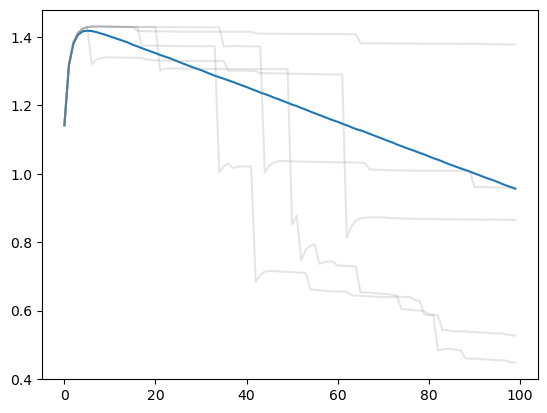

In [33]:
num_trials = 10000
all_errors = np.zeros((num_trials, epochs))

for trial in range(num_trials):
    x = x0.copy()
    for l in range(epochs):
        i = random.randint(0, n - 1)
        x = mats[i] @ x
        ratio = np.linalg.norm(x - x_star) / np.linalg.norm(x0 - x_star)
        all_errors[trial, l] = np.log(ratio)

mean_errors = all_errors.mean(axis=0)
plt.plot(mean_errors, label="mean log-error")
plt.plot(all_errors[:5].T, alpha=0.2, color="gray")  # a few sample paths